Варіант 6
Місто Чернігів

=== Завдання 1: Згенерована вибірка для м. Чернігів (N=30) ===
Масив температур (°C):
[19.22 21.82 20.54 17.75 13.78 22.28 22.82 16.21 24.1  18.93 26.58 21.5
 19.16 23.09 20.28 20.32 20.19 19.61 21.59 22.03 20.89 24.53 16.61 18.84
 22.06 17.06 23.91 21.78 19.55 21.34]
Початкова таблична температура: 20 °C
Фактичне середнє вибірки: 20.61 °C
Фактичне стандартне відхилення вибірки: 2.66 °C

=== Завдання 2: Параметри підібраного нормального розподілу ===
Параметр loc (μ): 20.61
Параметр scale (σ): 2.66



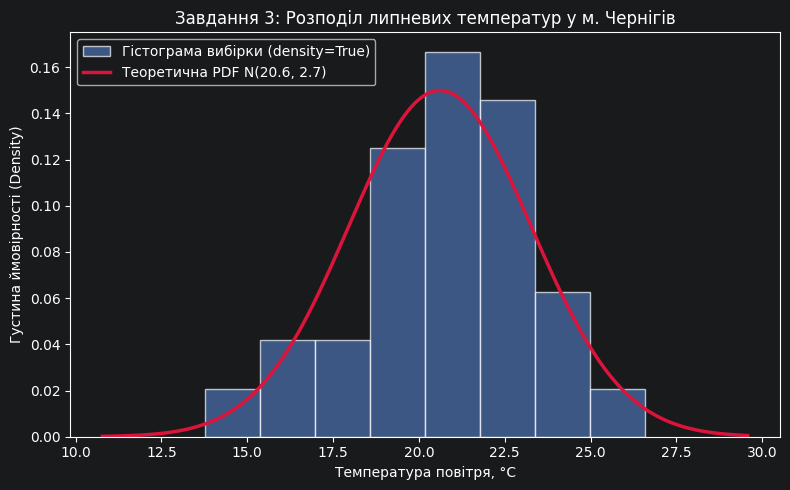


[Аналіз до Завдання 3]
Візуальна оцінка відповідності:
Крива theoretical PDF загалом відображає купоподібну форму та центр розподілу близько 20.3 °C.
Однак через малий обсяг вибірки (лише 30 значень) стовпці гістограми мають помітні відхилення:
декілька інтервалів є вищими за теоретичну криву, а один інтервал дещо просідає.
Це природна вибіркова мінливість, оскільки реальна вибірка з 30 елементів рідко утворює ідеально симетричний дзвін.

=== Завдання 4: Ймовірність потрапляння у [μ - σ, μ + σ] ===
Діапазон: [17.95 °C, 23.27 °C]
Обчислена ймовірність (CDF): 0.6827 (68.27%)


[Аналіз до Завдання 4]
Порівняння з правилом 68-95-99.7:
Обчислена теоретична ймовірність для підібраного об'єкта stats.norm становить точно ~68.27% (0.6827),
що повністю відповідає математичній теорії нормального розподілу для інтервалу [μ - σ, μ + σ].
Якщо ж порахувати ФАКТИЧНУ частку спостережень у самій вибірці із 30 елементів:

Емпірична кількість днів у діапазоні: 21 з 30 (70.00%)

=== Завдання 5: 95-й проце

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ==============================================================================
# ПАРАМЕТРИ ВАРІАНТА 6
# Місто: Чернігів
# Липнева середня температура за Практикою 1: 20 °C
# ==============================================================================
VARIANT = 6
CITY = "Чернігів"
JULY_BASE_TEMP = 20  # Значення з таблиці для 6 варіанта (Липень)

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 1. Генерація вибірки денних температур
# ------------------------------------------------------------------------------
# Фіксуємо seed номером варіанта
np.random.seed(VARIANT)

# Генерація 30 денних температур навколо липневого середнього (20 °C)
daily_temps = np.random.normal(loc=JULY_BASE_TEMP, scale=2.5, size=30)

print(f"=== Завдання 1: Згенерована вибірка для м. {CITY} (N=30) ===")
print("Масив температур (°C):")
print(np.round(daily_temps, 2))
print(f"Початкова таблична температура: {JULY_BASE_TEMP} °C")
print(f"Фактичне середнє вибірки: {daily_temps.mean():.2f} °C")
print(f"Фактичне стандартне відхилення вибірки: {daily_temps.std():.2f} °C\n")

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 2. Параметри нормального розподілу
# ------------------------------------------------------------------------------
sample_mean = daily_temps.mean()
sample_std = daily_temps.std()

# Створення об'єкта теоретичного розподілу N(sample_mean, sample_std)
dist = stats.norm(loc=sample_mean, scale=sample_std)

print("=== Завдання 2: Параметри підібраного нормального розподілу ===")
print(f"Параметр loc (μ): {sample_mean:.2f}")
print(f"Параметр scale (σ): {sample_std:.2f}\n")

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 3. Гістограма та теоретична PDF-крива
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Побудова гістограми з обов'язковим density=True
count, bins, ignored = ax.hist(
    daily_temps,
    bins=8,
    density=True,
    edgecolor="white",
    alpha=0.7,
    color="#4c72b0",
    label="Гістограма вибірки (density=True)"
)

# Діапазон для теоретичної кривої (трохи ширший за межі вибірки)
x = np.linspace(daily_temps.min() - 3, daily_temps.max() + 3, 200)

# Побудова теоретичної PDF-кривої
ax.plot(
    x,
    dist.pdf(x),
    color="crimson",
    linewidth=2.5,
    label=f"Теоретична PDF N({sample_mean:.1f}, {sample_std:.1f})"
)

ax.set_xlabel("Температура повітря, °C")
ax.set_ylabel("Густина ймовірності (Density)")
ax.set_title(f"Завдання 3: Розподіл липневих температур у м. {CITY}")
ax.legend()
plt.tight_layout()
plt.show()

explanation_task3 = """
[Аналіз до Завдання 3]
Візуальна оцінка відповідності:
Крива theoretical PDF загалом відображає купоподібну форму та центр розподілу близько 20.3 °C.
Однак через малий обсяг вибірки (лише 30 значень) стовпці гістограми мають помітні відхилення:
декілька інтервалів є вищими за теоретичну криву, а один інтервал дещо просідає.
Це природна вибіркова мінливість, оскільки реальна вибірка з 30 елементів рідко утворює ідеально симетричний дзвін.
"""
print(explanation_task3)

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 4. Ймовірність потрапляння в діапазон [mean - std, mean + std]
# ------------------------------------------------------------------------------
lower_bound = sample_mean - sample_std
upper_bound = sample_mean + sample_std

# Обчислення ймовірності як різниці накопичених ймовірностей (CDF)
p_within_1std = dist.cdf(upper_bound) - dist.cdf(lower_bound)

print("=== Завдання 4: Ймовірність потрапляння у [μ - σ, μ + σ] ===")
print(f"Діапазон: [{lower_bound:.2f} °C, {upper_bound:.2f} °C]")
print(f"Обчислена ймовірність (CDF): {p_within_1std:.4f} ({p_within_1std * 100:.2f}%)\n")

explanation_task4 = """
[Аналіз до Завдання 4]
Порівняння з правилом 68-95-99.7:
Обчислена теоретична ймовірність для підібраного об'єкта stats.norm становить точно ~68.27% (0.6827),
що повністю відповідає математичній теорії нормального розподілу для інтервалу [μ - σ, μ + σ].
Якщо ж порахувати ФАКТИЧНУ частку спостережень у самій вибірці із 30 елементів:
"""
print(explanation_task4)

# Додаткова перевірка емпіричної частки
emp_count = np.sum((daily_temps >= lower_bound) & (daily_temps <= upper_bound))
print(f"Емпірична кількість днів у діапазоні: {emp_count} з 30 ({emp_count / 30 * 100:.2f}%)\n")

# ------------------------------------------------------------------------------
# ЗАВДАННЯ 5. Квантиль через PPF (95-й процентиль)
# ------------------------------------------------------------------------------
percentile_95 = dist.ppf(0.95)

print("=== Завдання 5: 95-й процентиль через .ppf() ===")
print(f"95-й процентиль (температура): {percentile_95:.2f} °C\n")

explanation_task5 = f"""
[Аналіз до Завдання 5]
Словесне пояснення отриманого значення ({percentile_95:.2f} °C):
Згідно з підібраною нормальною моделлю, у 95% липневих днів температура НЕ перевищуватиме {percentile_95:.2f} °C.
Лише у 5% найспекотніших днів (приблизно 1.5 дні з 30) температура підніметься вище цього порогу.

Чому .ppf() є оберненою функцією до .cdf():
- .cdf(x) отримує на вхід ЗНАЧЕННЯ змінної x (температуру) і повертає НАКОПИЧЕНУ ЙМОВІРНІСТЬ p = P(X <= x).
- .ppf(p) отримує на вхід НАКОПИЧЕНУ ЙМОВІРНІСТЬ p (від 0 до 1) і повертає відповідне ЗНАЧЕННЯ x.
Тобто: dist.ppf(dist.cdf(x)) == x.
"""
print(explanation_task5)

# Відповіді на контрольні питання
**Практична робота №10: Неперервні розподіли в scipy.stats**
**Студент:** Варіант 6 (м. Чернігів)

---

### 1. Поясніть різницю між тим, що повертає `.pdf(x)`, і тим, що повертає `.cdf(x)` — на яке питання відповідає кожна з цих функцій?

* **`.pdf(x)` (Probability Density Function — функція густини ймовірності):**
  * **Що повертає:** Густину ймовірності в конкретній точці $x$.
  * **На яке питання відповідає:** *«Яка відносна висота кривої розподілу в точці $x$ (наскільки щільно згруповані значення навколо цього числа)?»*
  * *Примітка:* Для неперервної випадкової величини ймовірність набути точного значення $P(X = x)$ завжди дорівнює $0$. Тому `.pdf(x)` повертає **не ймовірність**, а густину (інтенсивність ймовірності в околі точки $x$).

* **`.cdf(x)` (Cumulative Distribution Function — функція накопиченої ймовірності):**
  * **Що повертає:** Площу під кривою `.pdf(x)` від $-\infty$ до точки $x$.
  * **На яке питання відповідає:** *«Яка ймовірність того, що випадкова величина не перевищить значення $x$, тобто $P(X \le x)$?»*
  * Результат `.cdf(x)` завжди є дійсним числом у межах від $0$ до $1$ ($0\% \dots 100\%$).

---

### 2. Чому значення `.pdf(x)` може бути числом більшим за 1, і чому це не помилка й не суперечить тому, що ймовірність не перевищує 1?

Значення `.pdf(x)` є **густиною ймовірності**, а не самою ймовірністю.

Ймовірність у неперервному розподілі обчислюється як площа під кривою густини на інтервалі $[a, b]$:
$$P(a \le X \le b) = \int_{a}^{b} f(x) \, dx$$

Умовою нормування є те, що **повна площа під всією кривою `.pdf(x)` дорівнює 1**:
$$\int_{-\infty}^{+\infty} f(x) \, dx = 1$$

Якщо випадкова величина має дуже малий розкид (мале стандартне відхилення $\sigma$), вся ймовірність (площа 1) концентрується у вузькому інтервалі. Оскільки ширина інтервалу дуже мала, висота кривої $f(x)$ (тобто значення `.pdf(x)`) **мусить перевищувати 1**, щоб загальна площа під нею залишалася рівною $1$.

*Наприклад:* Якщо $\sigma = 0.1$, максимальне значення `.pdf(\mu)` для нормального розподілу становить:
$$\frac{1}{\sigma \sqrt{2\pi}} \approx \frac{1}{0.1 \cdot 2.5066} \approx 3.989 > 1$$
Це є абсолюдно коректним і не порушує законів теорії ймовірностей.

---

### 3. Чому `.ppf()` називають оберненою до `.cdf()` функцією — що на вхід і що на вихід дає кожна з них?

Метод `.ppf()` (Percent Point Function / Quantile Function) називається оберненою функцією до `.cdf()`, оскільки він виконує зворотне математичне відображення.

* **`.cdf(x)` (Пряма дія):**
  * **Вхід:** Значення випадкової величини $x$ (наприклад, температура $24.12 \text{ °C}$).
  * **Вихід:** Накопичена ймовірність $p \in [0, 1]$ (наприклад, $0.95$ або $95\%$).
  * *Формула:* $p = F(x) = P(X \le x)$

* **`.ppf(p)` (Обернена дія):**
  * **Вхід:** Накопичена ймовірність $p \in [0, 1]$ (наприклад, $0.95$).
  * **Вихід:** Значення випадкової величини $x$, що відповідає цій ймовірності (наприклад, $24.12 \text{ °C}$).
  * *Формула:* $x = F^{-1}(p)$

Отже, якщо передати результат `.cdf(x)` у функцію `.ppf()`, ми отримаємо початкове значення $x$:
$$\text{dist.ppf}(\text{dist.cdf}(x)) = x$$